Compare repetition-centered lag-CRP curves for observed data and a matched control dataset.

Adjust `ctrl_query` to define alternative control populations.

Set `repetition_index` to 0 or 1 to focus on specific presentations.

In [7]:
import os

from jaxcmr.analyses.repcrp import plot_rep_crp
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.repetition import make_control_dataset


In [8]:
data_name = "LohnasKahana2014"
data_query = "data['list_type'] > 2"
ctrl_query = "data['list_type'] == 1"
min_lag = 4


In [9]:
project_root = find_project_root()
data_path = os.path.join(project_root, 'data', f'{data_name}.h5')
data = load_data(data_path)
trial_mask = generate_trial_mask(data, data_query)
control_dataset = make_control_dataset(data, data_query, ctrl_query, 10)
control_mask = generate_trial_mask(control_dataset, data_query)
datasets = [data, control_dataset]
masks = [trial_mask, control_mask]


/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)
/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


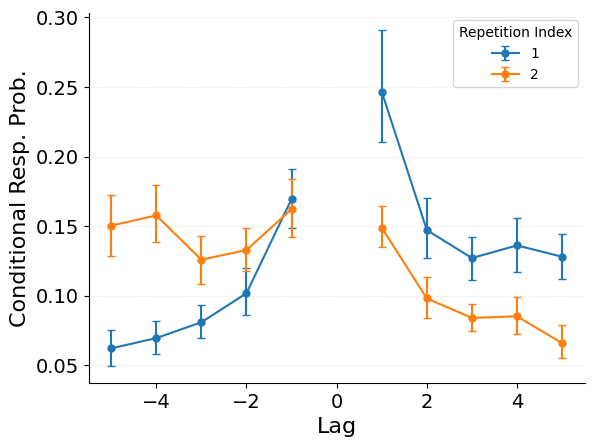

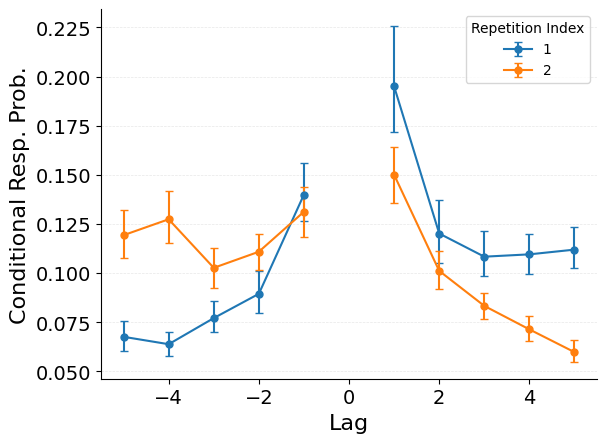

In [10]:
plot_rep_crp(
    datasets=data,
    trial_masks=trial_mask,
    min_lag=min_lag,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
plot_rep_crp(
    datasets=control_dataset,
    trial_masks=control_mask,
    min_lag=min_lag,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
);


In [11]:
import numpy as np
from jax import jit
from scipy import stats

from jaxcmr.analyses.repcrp import repcrp
from jaxcmr.helpers import apply_by_subject

# Parameters
max_lag = 5
size = 2

# Compute subject-level CRP values for observed and control datasets
observed_subject_values = apply_by_subject(
    data, trial_mask, jit(repcrp, static_argnames=("size",)), min_lag, size
)
control_subject_values = apply_by_subject(
    control_dataset, control_mask, jit(repcrp, static_argnames=("size",)), min_lag, size
)

# Get lag range from data
lag_range = int(np.max(data["listLength"][trial_mask])) - 1
lag_slice = slice(lag_range - max_lag, lag_range + max_lag + 1)
lag_labels = np.arange(-max_lag, max_lag + 1)

# Stack subject values and slice to lag range of interest
# Shape: [n_subjects, n_repetition_indices, n_lags]
for rep_idx, rep_label in enumerate(["First Presentation", "Second Presentation"]):
    observed_crp = np.vstack([s[rep_idx, lag_slice] for s in observed_subject_values])
    control_crp = np.vstack([s[rep_idx, lag_slice] for s in control_subject_values])

    print(f"\n{'='*60}")
    print(f"Statistical Tests: {rep_label}")
    print(f"{'='*60}")
    print(f"{'Lag':>5} | {'t-stat':>8} {'t p-val':>10} | {'W-stat':>8} {'W p-val':>10}")
    print(f"{'-'*5}-+-{'-'*20}-+-{'-'*20}")

    for lag_idx, lag in enumerate(lag_labels):
        obs = observed_crp[:, lag_idx]
        ctrl = control_crp[:, lag_idx]
        diff = obs - ctrl

        # Paired t-test
        t_stat, t_pval = stats.ttest_rel(obs, ctrl, nan_policy='omit')

        # Wilcoxon signed-rank test (handles NaN by removing pairs)
        valid = ~(np.isnan(obs) | np.isnan(ctrl))
        if valid.sum() > 10:
            w_stat, w_pval = stats.wilcoxon(diff[valid], alternative='two-sided')
        else:
            w_stat, w_pval = np.nan, np.nan

        print(f"{lag:>5} | {t_stat:>8.3f} {t_pval:>10.4f} | {w_stat:>8.1f} {w_pval:>10.4f}")


Statistical Tests: First Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val
------+----------------------+---------------------
   -5 |   -0.713     0.4810 |    239.0     0.2192
   -4 |    0.858     0.3970 |    260.0     0.3766
   -3 |    0.571     0.5715 |    284.0     0.6215
   -2 |    1.597     0.1194 |    240.0     0.2254
   -1 |    3.312     0.0022 |    138.0     0.0030
    0 |      nan        nan |      nan        nan
    1 |    3.825     0.0005 |    120.0     0.0010
    2 |    2.794     0.0085 |    155.0     0.0078
    3 |    2.673     0.0115 |    168.0     0.0151
    4 |    2.912     0.0063 |    138.0     0.0030
    5 |    1.800     0.0807 |    227.0     0.1535

Statistical Tests: Second Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val
------+----------------------+---------------------
   -5 |    3.061     0.0043 |    136.0     0.0027
   -4 |    3.765     0.0006 |    112.0     0.0006
   -3 |    2.971     0.0054 |    154.0     0.0074
   -2 |    2.768 

/var/folders/7n/m1dxq2r12b77t0c09mty9kn00000gn/T/ipykernel_1721/2940122538.py:43: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, t_pval = stats.ttest_rel(obs, ctrl, nan_policy='omit')


In [12]:
# Test: Is the First-Second bias greater in observed data than control?
# Compute (First - Second) difference for each subject in both conditions
observed_first = np.vstack([s[0, lag_slice] for s in observed_subject_values])
observed_second = np.vstack([s[1, lag_slice] for s in observed_subject_values])
control_first = np.vstack([s[0, lag_slice] for s in control_subject_values])
control_second = np.vstack([s[1, lag_slice] for s in control_subject_values])

observed_diff = observed_first - observed_second  # First-Second bias in observed
control_diff = control_first - control_second      # First-Second bias in control
effect = observed_diff - control_diff              # Difference of differences

print(f"\n{'='*70}")
print("Test: First-Second Bias (Observed) vs First-Second Bias (Control)")
print(f"{'='*70}")
print("H0: The preference for first-presentation neighbors over second-presentation")
print("    neighbors is the same in observed data as in the shuffled control.")
print(f"\n{'Lag':>5} | {'t-stat':>8} {'t p-val':>10} | {'W-stat':>8} {'W p-val':>10} | {'Mean Diff':>10}")
print(f"{'-'*5}-+-{'-'*20}-+-{'-'*20}-+-{'-'*11}")

for lag_idx, lag in enumerate(lag_labels):
    obs_d = observed_diff[:, lag_idx]
    ctrl_d = control_diff[:, lag_idx]
    diff_of_diff = effect[:, lag_idx]

    # Paired t-test comparing the biases
    t_stat, t_pval = stats.ttest_rel(obs_d, ctrl_d, nan_policy='omit')

    # Wilcoxon signed-rank test
    valid = ~(np.isnan(obs_d) | np.isnan(ctrl_d))
    if valid.sum() > 10:
        w_stat, w_pval = stats.wilcoxon(diff_of_diff[valid], alternative='two-sided')
    else:
        w_stat, w_pval = np.nan, np.nan

    mean_effect = np.nanmean(diff_of_diff)
    print(f"{lag:>5} | {t_stat:>8.3f} {t_pval:>10.4f} | {w_stat:>8.1f} {w_pval:>10.4f} | {mean_effect:>10.4f}")


Test: First-Second Bias (Observed) vs First-Second Bias (Control)
H0: The preference for first-presentation neighbors over second-presentation
    neighbors is the same in observed data as in the shuffled control.

  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -5 |   -2.768     0.0091 |    154.0     0.0074 |    -0.0364
   -4 |   -2.152     0.0386 |    194.0     0.0475 |    -0.0245
   -3 |   -2.177     0.0365 |    189.0     0.0387 |    -0.0194
   -2 |   -0.909     0.3696 |    252.0     0.3101 |    -0.0096
   -1 |   -0.104     0.9174 |    308.0     0.9163 |    -0.0014
    0 |      nan        nan |      nan        nan |        nan
    1 |    3.009     0.0049 |    142.0     0.0038 |     0.0527
    2 |    2.516     0.0168 |    170.0     0.0166 |     0.0300
    3 |    2.389     0.0226 |    191.0     0.0421 |     0.0179
    4 |    1.356     0.1840 |    214.0     0.1002 |     0.0127
    5 |    0.942     0.35

/var/folders/7n/m1dxq2r12b77t0c09mty9kn00000gn/T/ipykernel_1721/992345567.py:26: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, t_pval = stats.ttest_rel(obs_d, ctrl_d, nan_policy='omit')
/var/folders/7n/m1dxq2r12b77t0c09mty9kn00000gn/T/ipykernel_1721/992345567.py:35: RuntimeWarning: Mean of empty slice
  mean_effect = np.nanmean(diff_of_diff)
